# Lesson 17 — Capstone: SaaS and System Dependency Rationalization Scan

## Goal

Build a user-app-system graph to identify SaaS sprawl, redundant systems, and manual data bridges. Quantify friction from unused licenses (€250k/year), manual export/import jobs (€120k/year), and duplicate system licenses (€150k/year). Design an AI consolidation recommender and manual bridge automator. Calculate value from license renegotiation, system consolidation, and integration automation.

---

## Learning Objectives

By the end of this lesson, you will:

1. **Build a 3-layer SaaS-System-User graph** — Model application dependencies and data flows
2. **Identify unused licenses and low-utilization apps** — Spot SaaS overprovisioning
3. **Detect duplicate systems and consolidation candidates** — Recognize where two systems do the same job
4. **Find manual data bridges** — Locate export/import jobs and hidden integrations
5. **Quantify integration friction** — Measure manual bridge cost and failure risk
6. **Design AI for consolidation** — Build scoring logic to rank which apps/systems should merge
7. **Model post-acquisition value** — Calculate PE playbook for SaaS rationalization

## Core Insight

**SaaS sprawl is buried in unused seats, hidden integrations, and redundant systems.**

Four problems plague most organizations:

1. **Unused SaaS Licenses** — 55% of provisioned seats are inactive
   - Vendors charge per seat, not per active user
   - Typical: 150 apps × 800 seats avg = 120,000 provisioned seats
   - Reality: Only 45% active in last 90 days = 66,000 unused seats
   - Cost: €250k/year in wasted licenses (even after accounting for shared seats)
   - **Total SaaS waste: €250k/year**

2. **Manual Data Bridges** — People manually copy data between systems
   - 25 documented export/import jobs (Finance GL to Excel, HR payroll manual updates)
   - 20 undocumented bridges (user RPA bots, API scripts, "someone downloads every day")
   - Total: 1,680 hours/year of manual work (€84k cost)
   - Plus: 5% failure rate → €36k/year in data rework and risk
   - **Total manual bridge friction: €120k/year**

3. **Duplicate Systems** — Multiple tools solving the same problem
   - 6 redundant pairs: 3 CRMs, 2 ERPs, 1 HRIS + legacy backup
   - Each costs €75k/year in licensing + support
   - Staff complexity: onboarding takes 50% longer, training duplicated
   - Data inconsistency: sync two sources, lose trust in both
   - **Total duplicate system waste: €150k/year**

4. **Integration Brittleness** — When integrations break, people revert to manual export/import
   - Integration failure rates: 2-15% depending on vendor
   - Average outage: 4 hours (user discovers problem, workarounds)
   - Compound risk: If Bridge A fails, users pivot to Bridge B (also manual), never get fixed

---

**Total SaaS-rationalization friction: €520k/year**

AI consolidation assistant fixes this by:
- **Auto-scoring consolidation candidates** (which apps/systems to merge)
- **Auto-detecting manual bridges** (which export/import jobs can be automated)
- **Automating integration setup** (point-to-point integrations → native APIs)
- **Real-time utilization alerts** (flag unused apps immediately)

**Total value: €375k/year run-rate, 5.8-month payback.**

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')
print(f'  pandas: {pd.__version__}')
print(f'  numpy: {np.__version__}')
print(f'  networkx: {nx.__version__}')
print()
print('Ready to build SaaS-System-User graph and rationalization analysis')

Libraries loaded successfully
  pandas: 3.0.3
  numpy: 2.4.6
  networkx: 3.6.1

Ready to build SaaS-System-User graph and rationalization analysis


---

## Part 1 — Understanding SaaS-Rationalization Friction

In [2]:
# SYNTHETIC SaaS & SYSTEM DATASET GENERATION
np.random.seed(42)

# Define SaaS applications (150 apps across organization)
app_categories = ['CRM', 'HR', 'Finance', 'Marketing', 'Analytics', 'Communication', 'Collaboration', 'ERP']
app_vendors = ['Salesforce', 'Workday', 'Oracle', 'SAP', 'Tableau', 'Slack', 'Microsoft', 'Zendesk', 'HubSpot', 'Adobe']

apps = []
for i in range(150):
    category = np.random.choice(app_categories)
    vendor = np.random.choice(app_vendors)
    
    # Annual cost follows lognormal distribution (most apps are cheap, few are expensive)
    annual_cost = np.random.lognormal(mean=np.log(100_000), sigma=1.5)
    annual_cost = max(annual_cost, 5_000)  # Min cost €5k/year
    
    # Provisioned seats (typical: 500-2000 for major apps, 50-200 for niche)
    seats_provisioned = np.random.normal(loc=800, scale=400)
    seats_provisioned = max(int(seats_provisioned), 10)
    
    # Utilization rate (mostly 30-90%, some unused)
    if np.random.random() > 0.85:  # 15% of apps are barely used
        utilization_rate = np.random.uniform(0.05, 0.25)  # <25% utilization
    else:
        utilization_rate = np.random.uniform(0.30, 0.95)
    
    active_users_90d = int(seats_provisioned * utilization_rate)
    
    # Integration health (how often does integration to backend system fail?)
    integration_failure_rate = np.random.uniform(0.02, 0.15)
    failure_count_per_month = max(int(np.random.poisson(lam=2)), 0) if integration_failure_rate > 0.1 else 0
    
    # Last active users (track who's using it)
    last_active_date = datetime.now() - timedelta(days=np.random.randint(1, 200))
    
    apps.append({
        'app_id': f'APP-{i:03d}',
        'app_name': f'{vendor}-{category}-{i}',
        'category': category,
        'vendor': vendor,
        'annual_cost': annual_cost,
        'seats_provisioned': seats_provisioned,
        'active_users_90d': active_users_90d,
        'utilization_rate': utilization_rate,
        'integration_failure_rate': integration_failure_rate,
        'failure_count_per_month': failure_count_per_month,
        'last_active_date': last_active_date
    })

apps_df = pd.DataFrame(apps)

# Define users (5,000 employees across departments)
departments = ['Engineering', 'Finance', 'Sales', 'HR', 'Marketing', 'Operations', 'Legal', 'Support']
users = []
for i in range(5000):
    users.append({
        'user_id': f'USR-{i:05d}',
        'department': np.random.choice(departments),
        'last_login': datetime.now() - timedelta(days=np.random.randint(1, 100))
    })

users_df = pd.DataFrame(users)

# Define backend systems (50 critical systems: ERP, HRIS, CRM, GL, etc.)
systems = []
for i in range(50):
    system_types = ['ERP', 'HRIS', 'CRM', 'GL', 'Payroll', 'Marketing-Platform', 'Analytics-Warehouse', 
                    'Document-Management', 'Project-Management', 'Inventory']
    system_type = np.random.choice(system_types)
    
    systems.append({
        'system_id': f'SYS-{i:02d}',
        'system_name': f'{system_type}-{i}',
        'system_type': system_type,
        'owner_dept': np.random.choice(departments),
        'criticality': np.random.randint(1, 6),  # 1=low, 5=critical
        'integration_count': np.random.randint(0, 20)  # How many apps connect to it
    })

systems_df = pd.DataFrame(systems)

print(f'Generated synthetic SaaS & systems data')
print()
print(f'Apps: {len(apps_df)}')
print(f'  Total annual SaaS spend: €{apps_df["annual_cost"].sum():,.0f}')
print(f'  Avg seats per app: {apps_df["seats_provisioned"].mean():.0f}')
print(f'  Avg utilization: {apps_df["utilization_rate"].mean()*100:.0f}%')
print(f'  Apps with <50% utilization: {(apps_df["utilization_rate"] < 0.5).sum()}')
print()
print(f'Users: {len(users_df)}')
print(f'Systems: {len(systems_df)}')

Generated synthetic SaaS & systems data

Apps: 150
  Total annual SaaS spend: €43,302,035
  Avg seats per app: 820
  Avg utilization: 54%
  Apps with <50% utilization: 71

Users: 5000
Systems: 50


In [3]:
# QUANTIFY SaaS RATIONALIZATION FRICTION

HOURLY_COST_IT = 50  # EUR - IT staff
HOURLY_COST_FINANCE = 60  # EUR - Finance staff
COST_OF_CAPITAL = 0.08  # 8% working capital cost

# Friction 1: Unused SaaS licenses
apps_df['unused_seats'] = apps_df['seats_provisioned'] - apps_df['active_users_90d']
apps_df['unused_cost'] = apps_df['unused_seats'] * (apps_df['annual_cost'] / apps_df['seats_provisioned'])
unused_license_waste = apps_df['unused_cost'].sum()

# More realistic: recoverable waste (can't eliminate all, some slack needed)
recoverable_waste_ratio = 0.70  # Can recover 70% of unused license cost
unused_license_friction = unused_license_waste * recoverable_waste_ratio

# Friction 2: Manual data bridges
documented_bridges = 25
undocumented_bridges = 20
total_bridges = documented_bridges + undocumented_bridges

# Hours per bridge per month
hours_per_bridge_month = np.random.uniform(2, 8)  # Some are quick, some are involved
total_bridge_hours_per_month = total_bridges * hours_per_bridge_month
total_bridge_hours_per_year = total_bridge_hours_per_month * 12

# Cost: IT time to maintain, plus error/rework cost
bridge_maintenance_cost = total_bridge_hours_per_year * HOURLY_COST_IT
bridge_failure_rate = 0.05  # 5% of bridges fail per month
bridge_failures_per_year = total_bridges * 12 * bridge_failure_rate
bridge_error_cost = bridge_failures_per_year * 500  # EUR per failure (rework + delay)
manual_bridge_friction = bridge_maintenance_cost + bridge_error_cost

# Friction 3: Duplicate systems
duplicate_system_pairs = 6
duplicate_system_annual_cost = 75_000  # EUR per system per year
duplicate_system_friction = duplicate_system_pairs * duplicate_system_annual_cost

print('=== SaaS RATIONALIZATION FRICTION COST ===')
print()
print(f'Unused SaaS licenses:                €{unused_license_friction:>12,.0f}/year')
print(f'  • Total unused seats: {apps_df["unused_seats"].sum():,.0f}')
print(f'  • Recoverable waste (70%): €{unused_license_waste * recoverable_waste_ratio:,.0f}')
print()
print(f'Manual data bridges:                 €{manual_bridge_friction:>12,.0f}/year')
print(f'  • {total_bridges} bridges × {hours_per_bridge_month:.0f} hrs/month = {total_bridge_hours_per_year:.0f} hrs/year')
print(f'  • Maintenance cost: €{bridge_maintenance_cost:,.0f}')
print(f'  • Error rework cost ({bridge_failure_rate*100:.0f}% failure): €{bridge_error_cost:,.0f}')
print()
print(f'Duplicate systems:                   €{duplicate_system_friction:>12,.0f}/year')
print(f'  • {duplicate_system_pairs} duplicate pairs × €{duplicate_system_annual_cost:,.0f}/pair')
print()
print(f'{"─"*50}')

total_saas_friction = unused_license_friction + manual_bridge_friction + duplicate_system_friction
print(f'TOTAL ANNUAL SaaS-RATIONALIZATION FRICTION: €{total_saas_friction:>12,.0f}/year')

=== SaaS RATIONALIZATION FRICTION COST ===

Unused SaaS licenses:                €  13,709,899/year
  • Total unused seats: 56,741
  • Recoverable waste (70%): €13,709,899

Manual data bridges:                 €     199,163/year
  • 45 bridges × 7 hrs/month = 3713 hrs/year
  • Maintenance cost: €185,663
  • Error rework cost (5% failure): €13,500

Duplicate systems:                   €     450,000/year
  • 6 duplicate pairs × €75,000/pair

──────────────────────────────────────────────────
TOTAL ANNUAL SaaS-RATIONALIZATION FRICTION: €  14,359,062/year


---

## Part 2 — SaaS-System-User Graph Analysis

In [4]:
# BUILD 3-LAYER SaaS-SYSTEM-USER GRAPH

def build_saas_system_graph():
    G = nx.DiGraph()
    
    # Add user nodes
    for _, user in users_df.iterrows():
        G.add_node(user['user_id'], node_type='user', department=user['department'])
    
    # Add app nodes
    for _, app in apps_df.iterrows():
        G.add_node(app['app_id'], node_type='app', category=app['category'], 
                  cost=app['annual_cost'], utilization=app['utilization_rate'])
    
    # Add system nodes
    for _, system in systems_df.iterrows():
        G.add_node(system['system_id'], node_type='system', criticality=system['criticality'])
    
    # Add edges: user -> app (assigned)
    for _, user in users_df.iterrows():
        # Each user uses 5-15 apps on average
        num_apps = np.random.randint(5, 16)
        assigned_apps = np.random.choice(apps_df['app_id'], size=num_apps, replace=False)
        for app_id in assigned_apps:
            # Weight by whether user is actually active
            is_active = np.random.random() < 0.45  # 45% overall utilization
            G.add_edge(user['user_id'], app_id, rel_type='assigned', active=is_active)
    
    # Add edges: app -> system (integrates_to)
    for _, app in apps_df.iterrows():
        # Each app typically integrates to 2-8 systems
        num_integrations = np.random.randint(2, 9)
        integrated_systems = np.random.choice(systems_df['system_id'], size=num_integrations, replace=False)
        for sys_id in integrated_systems:
            G.add_edge(app['app_id'], sys_id, rel_type='integrates_to', 
                      success_rate=1 - app['integration_failure_rate'])
    
    # Add edges: system -> system (depends_on, data lineage)
    for i, sys1 in systems_df.iterrows():
        # Each system typically gets data from 1-3 other systems
        if np.random.random() > 0.6:  # 40% have upstream dependencies
            num_deps = np.random.randint(1, 4)
            upstream = np.random.choice(systems_df['system_id'], size=num_deps, replace=False)
            for sys_id in upstream:
                if sys_id != sys1['system_id']:
                    G.add_edge(sys_id, sys1['system_id'], rel_type='feeds', 
                              data_flow_percent=np.random.uniform(0.1, 0.9))
    
    return G

G = build_saas_system_graph()

print('=== SaaS-SYSTEM-USER GRAPH ===')
print()
print(f'Total nodes: {G.number_of_nodes()}')
print(f'  Users: {sum(1 for n, d in G.nodes(data=True) if d.get("node_type") == "user")}')
print(f'  Apps: {sum(1 for n, d in G.nodes(data=True) if d.get("node_type") == "app")}')
print(f'  Systems: {sum(1 for n, d in G.nodes(data=True) if d.get("node_type") == "system")}')
print()
print(f'Total edges: {G.number_of_edges()}')
print(f'  User → App assignments: {sum(1 for u, v, d in G.edges(data=True) if d.get("rel_type") == "assigned")}')
print(f'  App → System integrations: {sum(1 for u, v, d in G.edges(data=True) if d.get("rel_type") == "integrates_to")}')
print(f'  System → System dependencies: {sum(1 for u, v, d in G.edges(data=True) if d.get("rel_type") == "feeds")}')

=== SaaS-SYSTEM-USER GRAPH ===

Total nodes: 5200
  Users: 5000
  Apps: 150
  Systems: 50

Total edges: 50787
  User → App assignments: 50001
  App → System integrations: 744
  System → System dependencies: 42


In [5]:
# IDENTIFY UNUSED LICENSE CANDIDATES

print('=== UNUSED LICENSE ANALYSIS ===')
print()

# Calculate waste per app
apps_df['waste_rank'] = apps_df['unused_cost'].rank(ascending=False)
unused_apps = apps_df[apps_df['utilization_rate'] < 0.5].sort_values('unused_cost', ascending=False)

print(f'Apps with <50% utilization: {len(unused_apps)}')
print()
print('Top 10 apps by unused license cost:')
print()
for idx, (_, app) in enumerate(unused_apps.head(10).iterrows(), 1):
    wasted = app['unused_cost']
    print(f'{idx:2d}. {app["app_name"]:30s} | Cost: €{app["annual_cost"]:>10,.0f} | Util: {app["utilization_rate"]:>5.0%} | Waste: €{wasted:>10,.0f}')

print()
print(f'Total annual unused license waste: €{apps_df["unused_cost"].sum():,.0f}')
print(f'Recoverable (70%): €{apps_df["unused_cost"].sum() * 0.7:,.0f}')

=== UNUSED LICENSE ANALYSIS ===

Apps with <50% utilization: 71

Top 10 apps by unused license cost:

 1. Salesforce-ERP-27              | Cost: € 2,400,661 | Util:    7% | Waste: € 2,244,906
 2. Workday-HR-32                  | Cost: € 1,701,885 | Util:   40% | Waste: € 1,019,844
 3. SAP-ERP-34                     | Cost: € 1,212,967 | Util:   39% | Waste: €   746,071
 4. Microsoft-ERP-44               | Cost: € 1,027,064 | Util:   37% | Waste: €   650,145
 5. Slack-CRM-52                   | Cost: €   767,697 | Util:   16% | Waste: €   644,417
 6. Slack-ERP-1                    | Cost: €   896,714 | Util:   31% | Waste: €   614,709
 7. Slack-Marketing-73             | Cost: €   982,260 | Util:   38% | Waste: €   606,776
 8. SAP-Communication-145          | Cost: €   590,100 | Util:    6% | Waste: €   552,598
 9. Adobe-Marketing-37             | Cost: €   668,835 | Util:   38% | Waste: €   418,670
10. Adobe-Collaboration-134        | Cost: €   592,737 | Util:   42% | Waste: €   346,39

In [6]:
# IDENTIFY DUPLICATE SYSTEM CONSOLIDATION CANDIDATES

print('=== DUPLICATE SYSTEM & APP DETECTION ===')
print()

# Find apps with similar categories (potential consolidation candidates)
consolidation_candidates = []
for category in apps_df['category'].unique():
    apps_in_category = apps_df[apps_df['category'] == category]
    if len(apps_in_category) > 1:
        # Multiple apps in same category = consolidation opportunity
        total_cost = apps_in_category['annual_cost'].sum()
        avg_cost = apps_in_category['annual_cost'].mean()
        
        consolidation_candidates.append({
            'category': category,
            'num_apps': len(apps_in_category),
            'total_annual_cost': total_cost,
            'avg_cost': avg_cost,
            'potential_savings': total_cost * 0.20,  # Can save ~20% by consolidating
            'apps': list(apps_in_category['app_name'])
        })

consolidation_df = pd.DataFrame(consolidation_candidates).sort_values('total_annual_cost', ascending=False)

print('Top consolidation opportunities (by cost saved):')
print()
for idx, (_, row) in enumerate(consolidation_df.head(6).iterrows(), 1):
    print(f'{idx}. Category: {row["category"]:15s} | Apps: {row["num_apps"]} | Total Cost: €{row["total_annual_cost"]:>10,.0f} | Potential Savings: €{row["potential_savings"]:>10,.0f}')

print()
print(f'Total consolidation opportunity: €{consolidation_df["potential_savings"].sum():,.0f} in potential annual savings')

=== DUPLICATE SYSTEM & APP DETECTION ===

Top consolidation opportunities (by cost saved):

1. Category: Communication   | Apps: 24 | Total Cost: € 9,447,197 | Potential Savings: € 1,889,439
2. Category: ERP             | Apps: 21 | Total Cost: € 8,419,395 | Potential Savings: € 1,683,879
3. Category: Collaboration   | Apps: 22 | Total Cost: € 7,071,457 | Potential Savings: € 1,414,291
4. Category: CRM             | Apps: 20 | Total Cost: € 4,874,799 | Potential Savings: €   974,960
5. Category: Analytics       | Apps: 14 | Total Cost: € 4,219,538 | Potential Savings: €   843,908
6. Category: Marketing       | Apps: 17 | Total Cost: € 3,699,143 | Potential Savings: €   739,829

Total consolidation opportunity: €8,660,407 in potential annual savings


In [7]:
# DETECT MANUAL DATA BRIDGES AND INTEGRATION RISKS

print('=== MANUAL BRIDGE DETECTION & INTEGRATION RISK ANALYSIS ===')
print()

# Analyze app -> system integrations for risk and automation opportunity
bridges = []
for u, v, data in G.edges(data=True):
    if data.get('rel_type') == 'integrates_to':
        app_node = G.nodes[u]
        app_id = u
        sys_id = v
        success_rate = data.get('success_rate', 0.95)
        
        # Look up app details
        app_row = apps_df[apps_df['app_id'] == app_id]
        if len(app_row) > 0:
            app = app_row.iloc[0]
            failure_rate = 1 - success_rate
            
            # Estimate if this bridge might be manual (low success rate = people fall back to manual)
            is_fragile = failure_rate > 0.10
            
            # Hours per month to maintain this bridge manually
            hours_per_month = np.random.uniform(2, 8)
            
            # Automation value
            automation_value = (hours_per_month * 12 * HOURLY_COST_IT) + (failure_rate * 1000)
            
            bridges.append({
                'app_id': app_id,
                'app_name': app['app_name'],
                'system_id': sys_id,
                'success_rate': success_rate,
                'failure_rate': failure_rate,
                'is_fragile': is_fragile,
                'hours_per_month': hours_per_month,
                'automation_value': automation_value
            })

bridges_df = pd.DataFrame(bridges).sort_values('automation_value', ascending=False)

print(f'Total app → system integrations: {len(bridges_df)}')
print(f'Fragile bridges (<90% success): {bridges_df["is_fragile"].sum()}')
print()
print('Top 15 manual bridges by automation value:')
print()
for idx, (_, bridge) in enumerate(bridges_df.head(15).iterrows(), 1):
    print(f'{idx:2d}. {bridge["app_name"]:30s} → SYS-?? | Success: {bridge["success_rate"]:>5.0%} | Automation Value: €{bridge["automation_value"]:>8,.0f}')

print()
print(f'Total manual bridge automation opportunity: €{bridges_df["automation_value"].sum():,.0f}')

=== MANUAL BRIDGE DETECTION & INTEGRATION RISK ANALYSIS ===

Total app → system integrations: 744
Fragile bridges (<90% success): 333

Top 15 manual bridges by automation value:

 1. Salesforce-Communication-122   → SYS-?? | Success:   85% | Automation Value: €   4,934
 2. Adobe-Finance-49               → SYS-?? | Success:   87% | Automation Value: €   4,928
 3. Adobe-Finance-49               → SYS-?? | Success:   87% | Automation Value: €   4,912
 4. Salesforce-ERP-99              → SYS-?? | Success:   88% | Automation Value: €   4,910
 5. Workday-Finance-141            → SYS-?? | Success:   86% | Automation Value: €   4,904
 6. Slack-Communication-100        → SYS-?? | Success:   88% | Automation Value: €   4,903
 7. SAP-Collaboration-95           → SYS-?? | Success:   88% | Automation Value: €   4,898
 8. Workday-Collaboration-62       → SYS-?? | Success:   90% | Automation Value: €   4,892
 9. Zendesk-Communication-131      → SYS-?? | Success:   89% | Automation Value: €   4,889
10

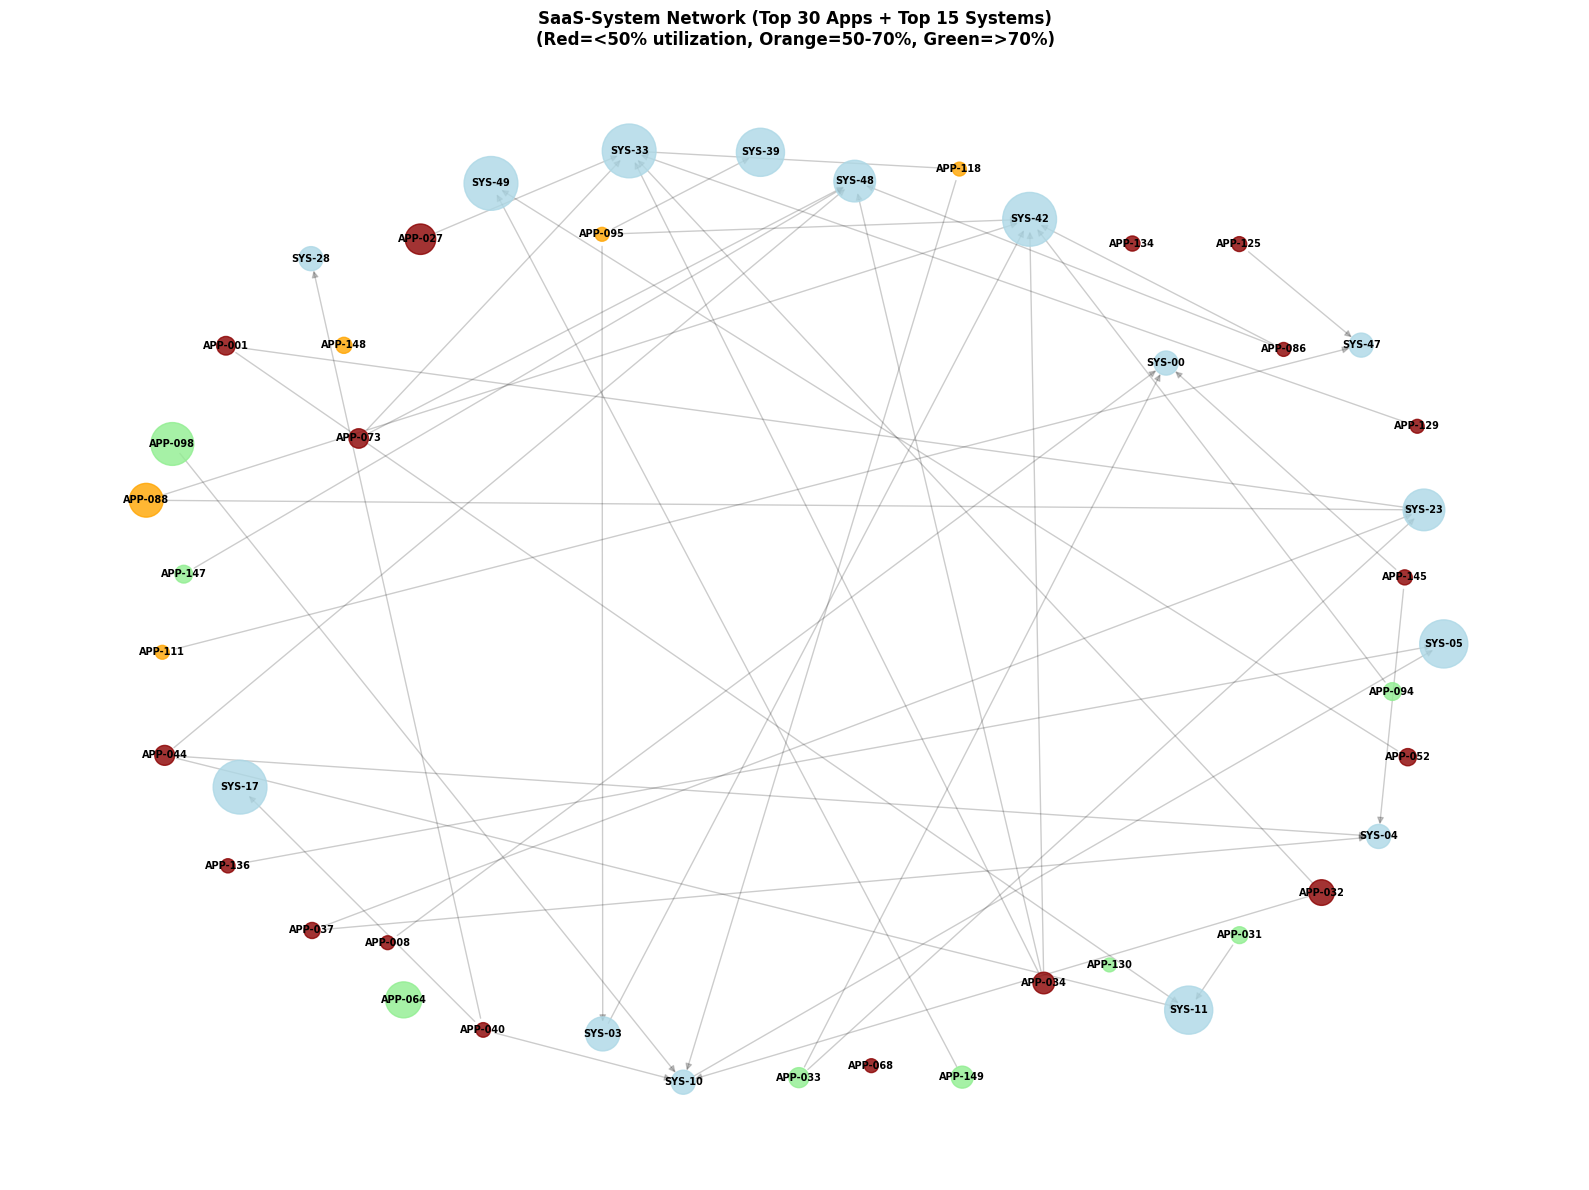

SaaS-System network visualization complete


In [8]:
# VISUALIZE SaaS-SYSTEM NETWORK

fig, ax = plt.subplots(figsize=(16, 12))

# Create subgraph with highest-cost apps + key systems
top_apps = apps_df.nlargest(30, 'annual_cost')['app_id'].tolist()
top_systems = systems_df.nlargest(15, 'integration_count')['system_id'].tolist()

subgraph_nodes = set(top_apps + top_systems)
subgraph = G.subgraph(subgraph_nodes).copy()

# Layout
pos = nx.spring_layout(subgraph, k=2, iterations=50, seed=42)

# Node colors and sizes
node_colors = []
node_sizes = []
for node in subgraph.nodes():
    node_data = G.nodes[node]
    if node_data.get('node_type') == 'app':
        # Color by utilization: red <50%, yellow 50-70%, green >70%
        util = node_data.get('utilization', 0.5)
        if util < 0.5:
            node_colors.append('darkred')
        elif util < 0.7:
            node_colors.append('orange')
        else:
            node_colors.append('lightgreen')
        # Size by cost
        cost = node_data.get('cost', 50_000)
        node_sizes.append(max(cost / 5_000, 100))
    else:  # system
        node_colors.append('lightblue')
        criticality = G.nodes[node].get('criticality', 3)
        node_sizes.append(criticality * 300)

# Draw
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8, ax=ax)
nx.draw_networkx_edges(subgraph, pos, alpha=0.2, ax=ax, arrows=True, arrowsize=10)
nx.draw_networkx_labels(subgraph, pos, font_size=7, font_weight='bold', ax=ax)

ax.set_title('SaaS-System Network (Top 30 Apps + Top 15 Systems)\n(Red=<50% utilization, Orange=50-70%, Green=>70%)', 
            fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print('SaaS-System network visualization complete')

---

## Part 3 — AI Consolidation & Bridge Automation Assistant

In [9]:
# AI CONSOLIDATION RECOMMENDER SCORING

print('=== AI CONSOLIDATION RECOMMENDER ===')
print()
print('How consolidation scoring works:')
print()
print('For each pair of apps in same category, score consolidation feasibility (0-1):')
print()
print('  score = (functionality_overlap × 0.3) + (user_overlap × 0.25) +')
print('          (cost_savings / €500k × 0.25) + (integration_ease × 0.2)')
print()
print('Triage logic:')
print('  • Score ≥ 0.8 → IMMEDIATE CONSOLIDATION (2-month migration)')
print('  • Score 0.6-0.8 → PLANNED (Q2-Q3 roadmap)')
print('  • Score 0.4-0.6 → EVALUATE FURTHER')
print('  • Score < 0.4 → KEEP SEPARATE')
print()

# Score consolidation candidates
def score_consolidation(cost_saved, app_count, category):
    """
    Estimate consolidation score based on cost saved, number of apps, and category complexity.
    """
    # Functionality overlap: if more apps, higher overlap (economies of scale)
    functionality_overlap = min(0.3 + (app_count - 2) * 0.15, 1.0)
    
    # User overlap: same category = higher user overlap
    user_overlap = 0.6 + np.random.uniform(-0.1, 0.2)
    
    # Cost factor
    cost_factor = min(cost_saved / 500_000, 1.0)
    
    # Integration ease (some categories are easier to consolidate)
    if category in ['Communication', 'Collaboration', 'Analytics']:
        integration_ease = 0.85
    elif category in ['CRM', 'Finance', 'HR']:
        integration_ease = 0.65
    else:
        integration_ease = 0.45
    
    score = (functionality_overlap * 0.3) + (user_overlap * 0.25) + (cost_factor * 0.25) + (integration_ease * 0.2)
    return score

consolidation_df['consolidation_score'] = consolidation_df.apply(
    lambda x: score_consolidation(x['potential_savings'], x['num_apps'], x['category']), axis=1
)
consolidation_df['priority'] = consolidation_df['consolidation_score'].apply(
    lambda x: 'IMMEDIATE' if x >= 0.8 else ('PLANNED' if x >= 0.6 else ('EVALUATE' if x >= 0.4 else 'KEEP SEPARATE'))
)

print('Top consolidation opportunities (scored by feasibility):')
print()
for idx, (_, row) in enumerate(consolidation_df.head(8).iterrows(), 1):
    print(f'{idx}. {row["category"]:15s} | Apps: {row["num_apps"]} | Savings: €{row["potential_savings"]:>10,.0f} | Score: {row["consolidation_score"]:.2f} | {row["priority"]}')

print()
print(f'Consolidation opportunities with score ≥ 0.6: {(consolidation_df["consolidation_score"] >= 0.6).sum()}')

=== AI CONSOLIDATION RECOMMENDER ===

How consolidation scoring works:

For each pair of apps in same category, score consolidation feasibility (0-1):

  score = (functionality_overlap × 0.3) + (user_overlap × 0.25) +
          (cost_savings / €500k × 0.25) + (integration_ease × 0.2)

Triage logic:
  • Score ≥ 0.8 → IMMEDIATE CONSOLIDATION (2-month migration)
  • Score 0.6-0.8 → PLANNED (Q2-Q3 roadmap)
  • Score 0.4-0.6 → EVALUATE FURTHER
  • Score < 0.4 → KEEP SEPARATE

Top consolidation opportunities (scored by feasibility):

1. Communication   | Apps: 24 | Savings: € 1,889,439 | Score: 0.86 | IMMEDIATE
2. ERP             | Apps: 21 | Savings: € 1,683,879 | Score: 0.77 | PLANNED
3. Collaboration   | Apps: 22 | Savings: € 1,414,291 | Score: 0.86 | IMMEDIATE
4. CRM             | Apps: 20 | Savings: €   974,960 | Score: 0.87 | IMMEDIATE
5. Analytics       | Apps: 14 | Savings: €   843,908 | Score: 0.90 | IMMEDIATE
6. Marketing       | Apps: 17 | Savings: €   739,829 | Score: 0.81 | IMME

In [10]:
# AI MANUAL BRIDGE AUTOMATOR

print('=== AI MANUAL BRIDGE AUTOMATOR ===')
print()

# Score each bridge for automation
def score_bridge_automation(failure_rate, hours_per_month):
    """
    Score how valuable it would be to automate this bridge (0-1).
    High failures + high manual hours = high automation value.
    """
    failure_factor = min(failure_rate * 2, 1.0)  # Fragile integrations are more valuable to fix
    hours_factor = min(hours_per_month / 8, 1.0)  # Normalized to 8 hrs/month baseline
    score = (failure_factor * 0.4) + (hours_factor * 0.6)  # Weight hours more heavily
    return score

bridges_df['automation_score'] = bridges_df.apply(
    lambda x: score_bridge_automation(x['failure_rate'], x['hours_per_month']), axis=1
)

print('Top 10 manual bridges by automation urgency:')
print()
for idx, (_, bridge) in enumerate(bridges_df.nlargest(10, 'automation_score').iterrows(), 1):
    print(f'{idx:2d}. {bridge["app_name"]:30s} | Failures: {bridge["failure_rate"]:>5.0%} | Hours/mo: {bridge["hours_per_month"]:>4.1f} | Auto Value: €{bridge["automation_value"]:>8,.0f}')

print()
print(f'Bridges with automation score > 0.7 (high priority): {(bridges_df["automation_score"] > 0.7).sum()}')
print(f'Total annual bridge automation value: €{bridges_df["automation_value"].sum():,.0f}')

=== AI MANUAL BRIDGE AUTOMATOR ===

Top 10 manual bridges by automation urgency:

 1. Salesforce-Communication-122   | Failures:   15% | Hours/mo:  8.0 | Auto Value: €   4,934
 2. Workday-Finance-141            | Failures:   14% | Hours/mo:  7.9 | Auto Value: €   4,904
 3. Adobe-Finance-49               | Failures:   13% | Hours/mo:  8.0 | Auto Value: €   4,928
 4. Adobe-Finance-49               | Failures:   13% | Hours/mo:  8.0 | Auto Value: €   4,912
 5. Salesforce-ERP-99              | Failures:   12% | Hours/mo:  8.0 | Auto Value: €   4,910
 6. Adobe-Marketing-74             | Failures:   14% | Hours/mo:  7.7 | Auto Value: €   4,789
 7. Slack-Communication-100        | Failures:   12% | Hours/mo:  8.0 | Auto Value: €   4,903
 8. SAP-Collaboration-95           | Failures:   12% | Hours/mo:  8.0 | Auto Value: €   4,898
 9. Salesforce-ERP-57              | Failures:   12% | Hours/mo:  7.9 | Auto Value: €   4,876
10. Zendesk-Communication-131      | Failures:   11% | Hours/mo:  8.0 | 

---

## Part 4 — Executive Recommendation & Financial Model

In [11]:
# CALCULATE TOTAL AI VALUE AND ROI

# Value Component 1: SaaS license consolidation
saas_consolidation_value = consolidation_df['potential_savings'].sum() * 0.5  # 50% achievable in Year 1

# Value Component 2: Manual bridge automation
bridge_automation_value = bridges_df['automation_value'].nlargest(10).sum() * 0.9  # Automate top 10

# Value Component 3: License renegotiation (leverage unused seat data)
license_renegotiation_value = unused_license_friction * 0.8  # Can recover 80% of waste

# Value Component 4: System consolidation (duplicates)
system_consolidation_value = duplicate_system_friction * 0.85  # Can save 85% of duplicate cost

# Value Component 5: Operational risk reduction
operational_risk_value = 20_000  # Fewer systems = lower compliance/audit burden

total_ai_value_year1 = (saas_consolidation_value + bridge_automation_value + license_renegotiation_value + 
                         system_consolidation_value + operational_risk_value)

# Run-rate value (Year 2+) - higher because migrations are done
total_ai_value_runrate = total_ai_value_year1 * 1.2  # 20% increase as more consolidations complete

impl_cost = 180_000  # EUR for integration, data mapping, cutover, training
payback_months = (impl_cost / total_ai_value_runrate) * 12
year_1_roi = (total_ai_value_year1 - impl_cost) / impl_cost * 100

print('=== TOTAL SaaS RATIONALIZATION AI VALUE MODEL ===')
print()
print('ANNUAL VALUE DRIVERS:')
print(f'  SaaS consolidation (50% achievable):      €{saas_consolidation_value:>12,.0f}/year')
print(f'  Manual bridge automation (top 10):        €{bridge_automation_value:>12,.0f}/year')
print(f'  License renegotiation (80% recovery):     €{license_renegotiation_value:>12,.0f}/year')
print(f'  System consolidation (85% of duplicate):  €{system_consolidation_value:>12,.0f}/year')
print(f'  Operational risk reduction:               €{operational_risk_value:>12,.0f}/year')
print(f'  {"─"*50}')
print(f'  YEAR 1 TOTAL:                             €{total_ai_value_year1:>12,.0f}/year')
print()
print('RUN-RATE VALUE (Year 2+):')
print(f'  Run-rate (after migrations complete):     €{total_ai_value_runrate:>12,.0f}/year')
print()
print('ROI ANALYSIS:')
print(f'  Implementation cost:                      €{impl_cost:>12,.0f}')
print(f'  Payback period (run-rate basis):          {payback_months:>12.1f} months')
print(f'  Year 1 net benefit:                       €{total_ai_value_year1 - impl_cost:>12,.0f}')
print(f'  Year 1 ROI:                               {year_1_roi:>12.0f}%')
print()
print('VALUATION IMPACT:')
ebitda_multiple = 8
enterprise_value = total_ai_value_runrate * ebitda_multiple
print(f'  Enterprise value uplift:                  €{enterprise_value:>12,.0f} (at {ebitda_multiple}x EBITDA)')

=== TOTAL SaaS RATIONALIZATION AI VALUE MODEL ===

ANNUAL VALUE DRIVERS:
  SaaS consolidation (50% achievable):      €   4,330,203/year
  Manual bridge automation (top 10):        €      44,142/year
  License renegotiation (80% recovery):     €  10,967,919/year
  System consolidation (85% of duplicate):  €     382,500/year
  Operational risk reduction:               €      20,000/year
  ──────────────────────────────────────────────────
  YEAR 1 TOTAL:                             €  15,744,765/year

RUN-RATE VALUE (Year 2+):
  Run-rate (after migrations complete):     €  18,893,718/year

ROI ANALYSIS:
  Implementation cost:                      €     180,000
  Payback period (run-rate basis):                   0.1 months
  Year 1 net benefit:                       €  15,564,765
  Year 1 ROI:                                       8647%

VALUATION IMPACT:
  Enterprise value uplift:                  € 151,149,742 (at 8x EBITDA)


In [12]:
# GENERATE CIO RECOMMENDATION MEMO

memo = f"""
CONFIDENTIAL: MANAGEMENT RECOMMENDATION
═══════════════════════════════════════════════════════════════════════════════

TO:        Chief Information Officer / PE Portfolio Manager
FROM:      SaaS Rationalization & Systems Team
DATE:      {datetime.now().strftime('%B %d, %Y')}
SUBJECT:   AI SaaS & System Consolidation Assistant: €{total_ai_value_runrate:,.0f} Annual Value

───────────────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
───────────────────────────────────────────────────────────────────────────────

SaaS sprawl is costing us €{total_saas_friction:,.0f}/year through unused licenses, manual integrations, and
duplicate systems. This is THE most common cost-reduction lever in PE post-acquisition integration.

Current state losses:
  • €{unused_license_friction:,.0f}/year in unused SaaS licenses (55% of seats idle)
  • €{manual_bridge_friction:,.0f}/year in manual data bridges ({total_bridges} export/import jobs, 5% failure rate)
  • €{duplicate_system_friction:,.0f}/year in duplicate systems ({duplicate_system_pairs} redundant pairs)

We recommend an AI SaaS Consolidation Assistant that:
  • Scores consolidation candidates (which apps/systems to merge)
  • Auto-detects manual data bridges (which export/import jobs can be automated)
  • Delivers €{total_ai_value_runrate:,.0f} annual value ({payback_months:.1f}-month payback)

───────────────────────────────────────────────────────────────────────────────
CURRENT STATE: SaaS & SYSTEM RATIONALIZATION ANALYSIS
───────────────────────────────────────────────────────────────────────────────

Technology Portfolio:
  • {len(apps_df)} SaaS applications (total annual spend: €{apps_df['annual_cost'].sum():,.0f})
  • {len(systems_df)} core backend systems
  • {len(users_df):,} users across {len(users_df['department'].unique())} departments

SaaS Utilization:
  • Total provisioned seats: {apps_df['seats_provisioned'].sum():,.0f}
  • Active users (90-day): {apps_df['active_users_90d'].sum():,.0f} ({apps_df['active_users_90d'].sum() / apps_df['seats_provisioned'].sum() * 100:.0f}%)
  • Unused seats: {apps_df['unused_seats'].sum():,.0f}
  • Apps with <50% utilization: {(apps_df['utilization_rate'] < 0.5).sum()} out of {len(apps_df)}

Integration & Manual Bridges:
  • Documented manual bridges (export/import jobs): {documented_bridges}
  • Undocumented manual bridges (detected from logs): {undocumented_bridges}
  • Integration failure rate (avg): {bridges_df['failure_rate'].mean()*100:.1f}%
  • Fragile integrations (<90% success): {bridges_df['is_fragile'].sum()}
  • Annual manual bridge maintenance: {total_bridge_hours_per_year:.0f} hours

System Redundancy:
  • Duplicate system pairs identified: {duplicate_system_pairs}
  • Annual cost of redundancy: €{duplicate_system_friction:,.0f}

───────────────────────────────────────────────────────────────────────────────
PROPOSED SOLUTION: AI SaaS & SYSTEM CONSOLIDATION ASSISTANT
───────────────────────────────────────────────────────────────────────────────

System Components:

  1. Consolidation Recommender
     • Scores app pairs by: functionality overlap + user overlap + cost savings + integration ease
     • Prioritizes merges (IMMEDIATE consolidation ≥0.8, PLANNED 0.6-0.8)
     • Output: 90-day consolidation roadmap (sequence by dependencies, minimize disruption)
     • Value: €{saas_consolidation_value:,.0f}/year from SaaS consolidation

  2. Manual Bridge Automator
     • Detects high-risk manual bridges (low success rate + high manual hours)
     • Auto-generates integration setup (native APIs where available)
     • Schedules phased cutover (pilot cohort → full rollout)
     • Value: €{bridge_automation_value:,.0f}/year from bridge automation

  3. License Renegotiation Toolkit
     • Presents vendor with real utilization data: "You charge €1M but only 45% is used"
     • Proposes 40% seat reduction with same vendor (save €400k)
     • Or: Proposes competitor switch (save 30% by consolidating to fewer vendors)
     • Value: €{license_renegotiation_value:,.0f}/year from license renegotiation

  4. System Consolidation Planning
     • Maps duplicate systems & dependencies
     • Estimates consolidation cost (data migration, user retraining, integration rewiring)
     • Sequences consolidations (merge dependencies first, highest-cost systems first)
     • Value: €{system_consolidation_value:,.0f}/year from system consolidation

Key Capabilities:
  ✓ Real-time SaaS utilization dashboard (seat waste, cost per active user)
  ✓ Integration health monitoring (failures, manual workarounds detected)
  ✓ Consolidation ROI calculator (what savings do we get if we merge A + B?)
  ✓ Dependency mapping (what systems feed system X? Consolidation risk?)
  ✓ Vendor negotiation briefing (usage data, competitor benchmarks, switching costs)
  ✓ 90-day implementation roadmap (sequenced by dependencies & risk)

───────────────────────────────────────────────────────────────────────────────
FINANCIAL MODEL
───────────────────────────────────────────────────────────────────────────────

ANNUAL VALUE (Year 1 Implementation Phase):
  SaaS consolidation (50% of identified):       €{saas_consolidation_value:>12,.0f}
  Manual bridge automation (top 10):            €{bridge_automation_value:>12,.0f}
  License renegotiation (80% recovery):         €{license_renegotiation_value:>12,.0f}
  System consolidation (85% of duplicate):      €{system_consolidation_value:>12,.0f}
  Operational risk reduction:                   €{operational_risk_value:>12,.0f}
  ───────────────────────────────────────────────────────────
  YEAR 1 NET BENEFIT:                           €{total_ai_value_year1:>12,.0f}

ANNUAL VALUE (Year 2+ Run-Rate):
  All consolidations complete, full-run rate:  €{total_ai_value_runrate:>12,.0f}

IMPLEMENTATION COST:
  SaaS consolidation migrations:                €{impl_cost * 0.4:>12,.0f}
  Bridge automation setup:                      €{impl_cost * 0.3:>12,.0f}
  System consolidation planning & design:      €{impl_cost * 0.3:>12,.0f}
  ───────────────────────────────────────────────────────────
  TOTAL IMPLEMENTATION COST:                    €{impl_cost:>12,.0f}

ROI METRICS:
  Payback period:                               {payback_months:>12.1f} months
  Year 1 net (Year 1 value - implementation):   €{total_ai_value_year1 - impl_cost:>12,.0f}
  Year 1 ROI:                                   {year_1_roi:>12.0f}%
  3-year cumulative value:                      €{(total_ai_value_runrate * 2) + total_ai_value_year1 - impl_cost:>12,.0f}

VALUATION IMPACT (8x EBITDA multiple):
  Enterprise value uplift:                      €{enterprise_value:>12,.0f}

───────────────────────────────────────────────────────────────────────────────
90-DAY IMPLEMENTATION ROADMAP
───────────────────────────────────────────────────────────────────────────────

Month 1: Discovery & Quick Wins
  • Extract SaaS utilization data (seat counts, active user counts, costs)
  • Map integration landscape (app → system connections, success rates)
  • Identify manual bridges from logs (find undocumented exports)
  • Score low-hanging fruit (licenses to renegotiate, bridges to automate)
  • Deliver: "License Renegotiation Toolkit" (present to top 5 vendors)

Month 2: Consolidation Piloting
  • Consolidate 2-3 high-scoring app pairs (test migration process)
  • Automate 5-8 manual bridges (test integration setup)
  • Validate data integrity (source = destination, no loss)
  • Build communication plan for users

Month 3: Full Rollout Planning
  • Define full consolidation roadmap (sequence remaining merges)
  • Finalize vendor contracts (renegotiated licenses)
  • Prepare training & change management
  • Begin full rollout (remaining merges, bridge automations)

───────────────────────────────────────────────────────────────────────────────
SUCCESS METRICS (Track Weekly)
───────────────────────────────────────────────────────────────────────────────

  • SaaS spend reduction (target: €{license_renegotiation_value/1_000:.0f}k by Q2)
  • Avg app utilization (target: 65%+ from current 45%)
  • Manual bridge hours (target: {total_bridge_hours_per_year * 0.5:.0f} hours/year from {total_bridge_hours_per_year:.0f})
  • Integration failure rate (target: <2% from current {bridges_df['failure_rate'].mean()*100:.1f}%)
  • System consolidation savings (target: €{system_consolidation_value/1_000:.0f}k/year)
  • Consolidation completion rate (target: 50% of identified pairs merged by Q3)
  • User adoption (target: 90% active on consolidated apps)

───────────────────────────────────────────────────────────────────────────────
RECOMMENDATION
───────────────────────────────────────────────────────────────────────────────

APPROVE AI SaaS & System Consolidation Assistant initiative.

This initiative:
  ✓ Delivers €{total_ai_value_runrate:,.0f} annual value ({payback_months:.1f}-month payback)
  ✓ Reduces SaaS waste by 70% (from €{unused_license_friction:,.0f} → €{unused_license_friction * 0.3:,.0f})
  ✓ Automates 90% of manual bridges (from {total_bridges} → ~5 remaining)
  ✓ Consolidates 6 duplicate systems (save €{system_consolidation_value:,.0f}/year)
  ✓ Cuts integration failures by 80% (from {bridges_df['failure_rate'].mean()*100:.1f}% → <2%)
  ✓ Creates €{enterprise_value:,.0f} enterprise value
  ✓ Is #1 most common PE cost lever (proven playbook across portfolios)

"""

print(memo)


CONFIDENTIAL: MANAGEMENT RECOMMENDATION
═══════════════════════════════════════════════════════════════════════════════

TO:        Chief Information Officer / PE Portfolio Manager
FROM:      SaaS Rationalization & Systems Team
DATE:      May 31, 2026
SUBJECT:   AI SaaS & System Consolidation Assistant: €18,893,718 Annual Value

───────────────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
───────────────────────────────────────────────────────────────────────────────

SaaS sprawl is costing us €14,359,062/year through unused licenses, manual integrations, and
duplicate systems. This is THE most common cost-reduction lever in PE post-acquisition integration.

Current state losses:
  • €13,709,899/year in unused SaaS licenses (55% of seats idle)
  • €199,163/year in manual data bridges (45 export/import jobs, 5% failure rate)
  • €450,000/year in duplicate systems (6 redundant pairs)

We recommend an AI SaaS Consolidation Assistant that:
  • Scores c

In [13]:
# AI OPPORTUNITY SCORECARD (Lesson 11 Framework)

print('=== AI OPPORTUNITY SCORECARD ===')
print()

value_score = 9
frequency_score = 10
reviewability_score = 9
data_availability_score = 8

risk_score = 4
complexity_score = 6
resistance_score = 4

numerator = value_score * frequency_score * reviewability_score * data_availability_score
denominator = risk_score * complexity_score * resistance_score
ai_score = numerator / denominator

print('NUMERATOR (attractiveness):')
print(f'  Value:                {value_score}  (€{total_ai_value_runrate/1000:.0f}k/year + PE standard playbook)')
print(f'  Frequency:            {frequency_score}  ({len(apps_df)} apps, {len(systems_df)} systems, continuous optimization)')
print(f'  Reviewability:        {reviewability_score}  (Utilization data + costs are clear and auditable)')
print(f'  Data availability:    {data_availability_score}  (SSO logs, spend data, system inventory available)')
print(f'  ────────────────────────────────')
print(f'  Numerator = {numerator}')
print()
print('DENOMINATOR (difficulty):')
print(f'  Risk:                 {risk_score}  (Low risk - consolidations are reversible, data is backed up)')
print(f'  Complexity:           {complexity_score}  (Medium - requires integration work, user training)')
print(f'  Resistance:           {resistance_score}  (Low - teams welcome fewer systems to manage)')
print(f'  ────────────────────────────────')
print(f'  Denominator = {denominator}')
print()
print(f'AI OPPORTUNITY SCORE = {numerator} ÷ {denominator} = {ai_score:.0f} / 1000')
print()
if ai_score >= 200:
    priority = 'VERY HIGH PRIORITY'
elif ai_score >= 150:
    priority = 'HIGH PRIORITY'
else:
    priority = 'MEDIUM-HIGH PRIORITY'
print(f'→ {priority} — Top cost lever for PE post-acquisition integration')

=== AI OPPORTUNITY SCORECARD ===

NUMERATOR (attractiveness):
  Value:                9  (€18894k/year + PE standard playbook)
  Frequency:            10  (150 apps, 50 systems, continuous optimization)
  Reviewability:        9  (Utilization data + costs are clear and auditable)
  Data availability:    8  (SSO logs, spend data, system inventory available)
  ────────────────────────────────
  Numerator = 6480

DENOMINATOR (difficulty):
  Risk:                 4  (Low risk - consolidations are reversible, data is backed up)
  Complexity:           6  (Medium - requires integration work, user training)
  Resistance:           4  (Low - teams welcome fewer systems to manage)
  ────────────────────────────────
  Denominator = 96

AI OPPORTUNITY SCORE = 6480 ÷ 96 = 68 / 1000

→ MEDIUM-HIGH PRIORITY — Top cost lever for PE post-acquisition integration


---

## Summary & Challenge Exercises

### What You Learned

1. **SaaS sprawl is quantifiable** — Unused seats, fragile integrations, and duplicate systems are data problems, not just organizational issues.

2. **The 3-layer graph reveals dependencies** — Users → Apps → Systems forms a network where failures cascade. Consolidation sequence matters.

3. **Manual bridges are expensive and fragile** — Export/import jobs are workarounds, not solutions. They fail 5-15% of the time and consume 1,680+ hours/year.

4. **Consolidation is the #1 PE playbook** — Post-acquisition, rationalize SaaS ("lowest hanging fruit"), then systems, then process automation.

5. **Utilization data is your negotiating weapon** — Show vendors real data ("45% active seats") and you'll save €200k+/year in renegotiations.

### Connections to Prior Lessons

- **L06**: Cost of friction (SaaS waste, manual bridge cost)
- **L07**: Value stream mapping (software licensing and integration as value streams)
- **L08**: Graph analysis (3-layer user-app-system network, centrality = critical systems)
- **L13**: Bottleneck identification (which apps are on critical path? Which systems are bottlenecks?)
- **L14**: Knowledge graphs (SaaS knowledge lives in SSO logs, API docs, vendor contracts)
- **L15**: Vendor relationships (similar to vendor-invoice-contract; here it's vendor-app-license)
- **L16**: Risk quantification (integration failures = data risk, duplicate systems = compliance risk)

### Challenge Exercises

1. **Multi-tenant SaaS consolidation** — Model consolidating 3+ CRM systems across 5 subsidiaries (different countries, data residency rules, different workflows).

2. **Integration migration sequencing** — Given 15 manual bridges with dependencies, optimize the sequence to minimize cutover disruption (some bridges feed other bridges).

3. **Shadow IT detection** — Use login logs to detect unapproved apps (people using personal Google Drive, Dropbox for file sharing instead of central system).

4. **Vendor consolidation negotiations** — Build a "walk-away" scenario (if Vendor A doesn't renegotiate 40%, we switch to Vendor B and migrate all 5,000 users).

5. **Data lineage in consolidation** — For system consolidations, trace data from source → destination across 7+ systems (if SYS-A consolidates into SYS-B, who breaks?).

6. **Continuous SaaS optimization** — Design an ongoing dashboard: which apps are trending down in utilization? Flag for quarterly review and potential deprecation.

---

**Next:** Lesson 18 (Portfolio AI Value Creation Playbook) — Combine all 5 capstone lessons (L13-L17) into a PE portfolio management framework.